In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../data/processed/cleaned_superstore.csv")

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed"
)

monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Order Date",
            freq="MS"
        )
    )["Sales"]
    .sum()
)

monthly_sales = monthly_sales.sort_index()

print(monthly_sales)
print("Number of months:", len(monthly_sales))

Order Date
2014-01-01     14236.8950
2014-02-01      4519.8920
2014-03-01     55691.0090
2014-04-01     28295.3450
2014-05-01     23648.2870
2014-06-01     34595.1276
2014-07-01     33946.3930
2014-08-01     27909.4685
2014-09-01     81777.3508
2014-10-01     31453.3930
2014-11-01     78628.7167
2014-12-01     69545.6205
2015-01-01     18174.0756
2015-02-01     11951.4110
2015-03-01     38726.2520
2015-04-01     34195.2085
2015-05-01     30131.6865
2015-06-01     24797.2920
2015-07-01     28765.3250
2015-08-01     36898.3322
2015-09-01     64595.9180
2015-10-01     31404.9235
2015-11-01     75972.5635
2015-12-01     74919.5212
2016-01-01     18542.4910
2016-02-01     22978.8150
2016-03-01     51715.8750
2016-04-01     38750.0390
2016-05-01     56987.7280
2016-06-01     40344.5340
2016-07-01     39261.9630
2016-08-01     31115.3743
2016-09-01     73410.0249
2016-10-01     59687.7450
2016-11-01     79411.9658
2016-12-01     96999.0430
2017-01-01     43971.3740
2017-02-01     20301.1334
2

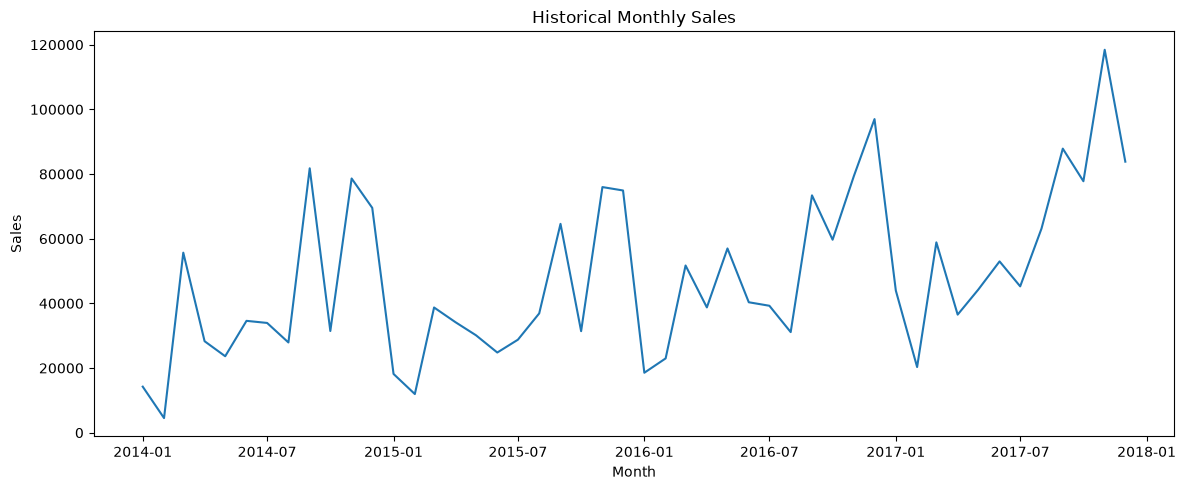

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Historical Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [4]:
train = monthly_sales.iloc[:-12]
test = monthly_sales.iloc[-12:]

print("Training months:", len(train))
print("Testing months:", len(test))

Training months: 36
Testing months: 12


In [5]:
model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

model_fit = model.fit(
    optimized=True
)

print("Forecasting model trained successfully!")

Forecasting model trained successfully!


In [6]:
test_predictions = model_fit.forecast(
    len(test)
)

print(test_predictions)

2017-01-01     33012.376555
2017-02-01     31282.397250
2017-03-01     65132.698700
2017-04-01     53344.454683
2017-05-01     58759.699041
2017-06-01     53251.033112
2017-07-01     55951.694353
2017-08-01     55904.835202
2017-09-01     97898.891682
2017-10-01     63036.221950
2017-11-01    103999.635610
2017-12-01    104357.684062
Freq: MS, dtype: float64


In [7]:
mae = mean_absolute_error(
    test,
    test_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        test_predictions
    )
)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 11453.69
RMSE: 12541.79


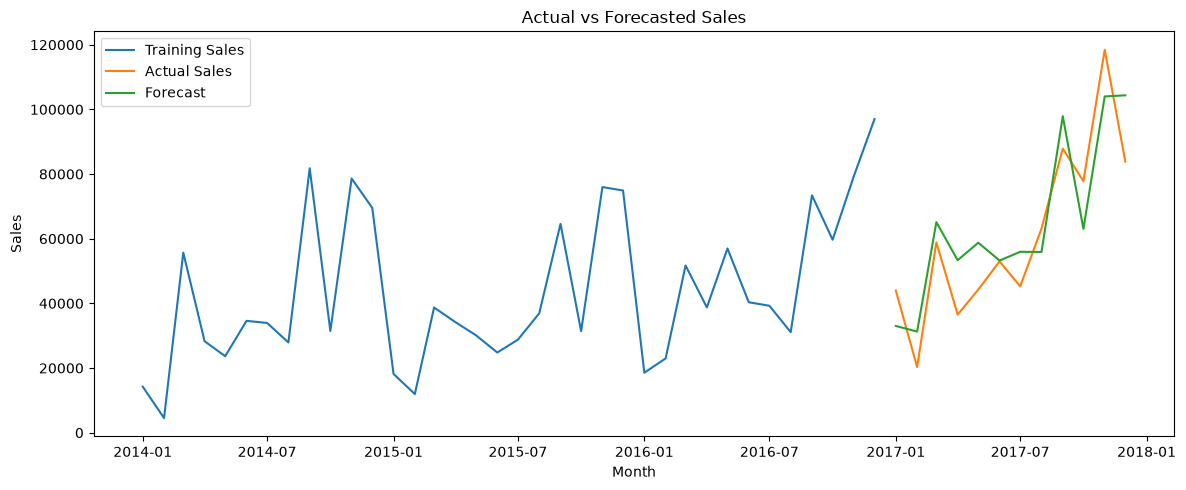

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train.values,
    label="Training Sales"
)

plt.plot(
    test.index,
    test.values,
    label="Actual Sales"
)

plt.plot(
    test.index,
    test_predictions,
    label="Forecast"
)

plt.title("Actual vs Forecasted Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
final_model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

final_model_fit = final_model.fit(
    optimized=True
)

future_forecast = final_model_fit.forecast(6)

print("Next 6 Months Forecast:")
print(future_forecast)

Next 6 Months Forecast:
2018-01-01    49693.654720
2018-02-01    41839.975569
2018-03-01    74872.554375
2018-04-01    61537.825260
2018-05-01    68507.951543
2018-06-01    65394.613439
Freq: MS, dtype: float64


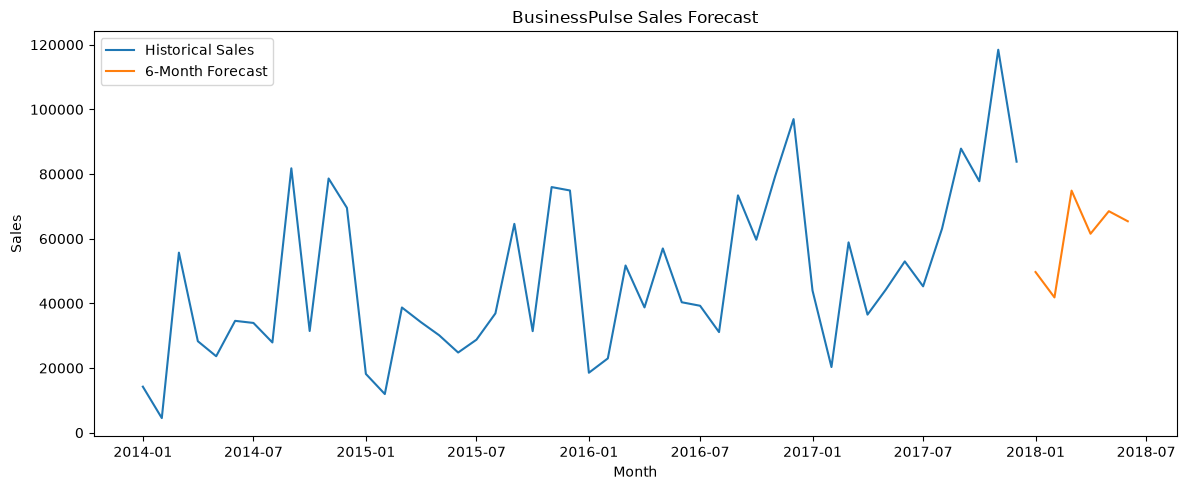

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    label="Historical Sales"
)

plt.plot(
    future_forecast.index,
    future_forecast.values,
    label="6-Month Forecast"
)

plt.title("BusinessPulse Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
forecast_df = future_forecast.reset_index()

forecast_df.columns = [
    "Forecast Month",
    "Forecast Sales"
]

forecast_df["Forecast Sales"] = forecast_df[
    "Forecast Sales"
].round(2)

forecast_df.to_csv(
    "../data/processed/sales_forecast.csv",
    index=False
)

print("Forecast saved successfully!")

Forecast saved successfully!
